In [3]:
# Numerical computing library
# Used to work with arrays, math operations, and matrices
import numpy as np  

# Used to draw graphs (scatter plot, curve, etc.)
import matplotlib.pyplot as plt  

# Splits data into training and testing sets
from sklearn.model_selection import train_test_split  

# LinearRegression = normal equation based linear model
# SGDRegressor = gradient descent based linear model
from sklearn.linear_model import LinearRegression, SGDRegressor  

# PolynomialFeatures = creates x², x³, etc.
# StandardScaler = scales features to mean=0, std=1
from sklearn.preprocessing import PolynomialFeatures, StandardScaler  

# Used to measure how good the model is (R² score)
from sklearn.metrics import r2_score  

# Pipeline = chains steps like scaling → polynomial → model
from sklearn.pipeline import Pipeline  


In [4]:
# Create 200 random numbers between -3 and +3
# Shape = (200 rows, 1 column)
X = 6 * np.random.rand(200, 1) - 3  

# Create target y using a quadratic formula:
# y = 0.8x² + 0.9x + 2
# + random noise to make it look like real-world data
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)


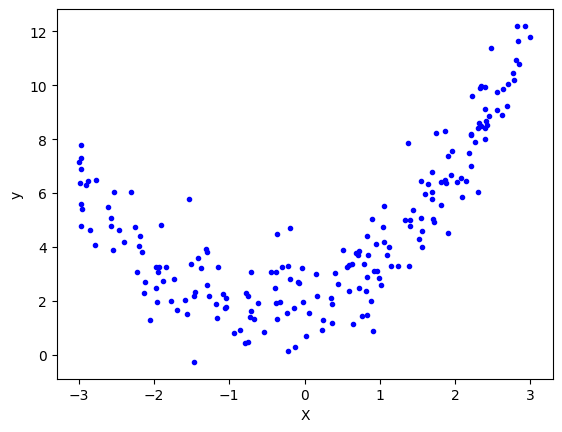

In [5]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [6]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
# Applying linear regression
lr = LinearRegression()

In [8]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.2534019725014347

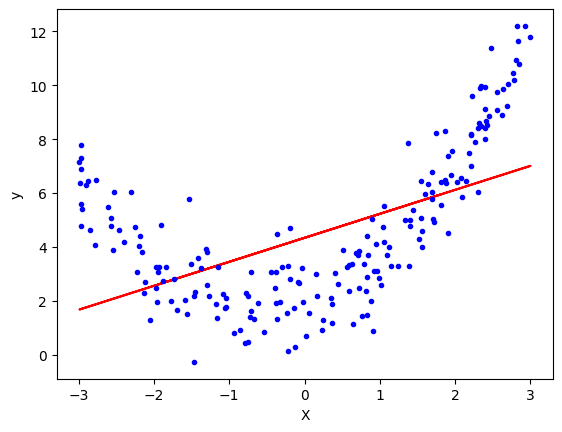

In [10]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [11]:
# Create a polynomial feature generator of degree 2
# degree=2 → it will create: 1, x, x²
# include_bias=True → adds the column of 1s (for intercept)
poly = PolynomialFeatures(degree=2, include_bias=True)

# Learn how to transform X_train and then apply it
# Example: x → [1, x, x²]
X_train_trans = poly.fit_transform(X_train)

# Apply the SAME transformation to test data
X_test_trans = poly.transform(X_test)


In [12]:
# Print the original first training sample (just x)
print(X_train[0])

# Print the transformed version (1, x, x²)
print(X_train_trans[0])


[1.80697804]
[1.         1.80697804 3.26516965]


In [14]:
# include_bias parameter

In [13]:
# Create a linear regression model object
lr = LinearRegression()

# Train the model using polynomial features
# It learns the best weights for: 1, x, x²
lr.fit(X_train_trans, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# Use the trained model to predict y values
# for the polynomial-transformed test data
y_pred = lr.predict(X_test_trans)


In [15]:
# Calculate R² score between real y and predicted y
r2_score(y_test, y_pred)


0.8282023214049811

In [16]:
# Print the learned weights for x and x²
print(lr.coef_)

# Print the learned intercept (bias term)
print(lr.intercept_)


[[0.         0.88346248 0.80566244]]
[1.95586274]


In [17]:
# Create 200 evenly spaced x values from -3 to +3
# This is just for smooth plotting
X_new = np.linspace(-3, 3, 200).reshape(200, 1)

# Convert these x values into polynomial features: [1, x, x²]
X_new_poly = poly.transform(X_new)

# Predict y values for these smooth x points
y_new = lr.predict(X_new_poly)


In [20]:
# print(X_new)
print(X_new_poly)

[[ 1.00000000e+00 -3.00000000e+00  9.00000000e+00]
 [ 1.00000000e+00 -2.96984925e+00  8.82000455e+00]
 [ 1.00000000e+00 -2.93969849e+00  8.64182723e+00]
 [ 1.00000000e+00 -2.90954774e+00  8.46546804e+00]
 [ 1.00000000e+00 -2.87939698e+00  8.29092700e+00]
 [ 1.00000000e+00 -2.84924623e+00  8.11820409e+00]
 [ 1.00000000e+00 -2.81909548e+00  7.94729931e+00]
 [ 1.00000000e+00 -2.78894472e+00  7.77821267e+00]
 [ 1.00000000e+00 -2.75879397e+00  7.61094417e+00]
 [ 1.00000000e+00 -2.72864322e+00  7.44549380e+00]
 [ 1.00000000e+00 -2.69849246e+00  7.28186157e+00]
 [ 1.00000000e+00 -2.66834171e+00  7.12004747e+00]
 [ 1.00000000e+00 -2.63819095e+00  6.96005151e+00]
 [ 1.00000000e+00 -2.60804020e+00  6.80187369e+00]
 [ 1.00000000e+00 -2.57788945e+00  6.64551400e+00]
 [ 1.00000000e+00 -2.54773869e+00  6.49097245e+00]
 [ 1.00000000e+00 -2.51758794e+00  6.33824903e+00]
 [ 1.00000000e+00 -2.48743719e+00  6.18734375e+00]
 [ 1.00000000e+00 -2.45728643e+00  6.03825661e+00]
 [ 1.00000000e+00 -2.42713568e+

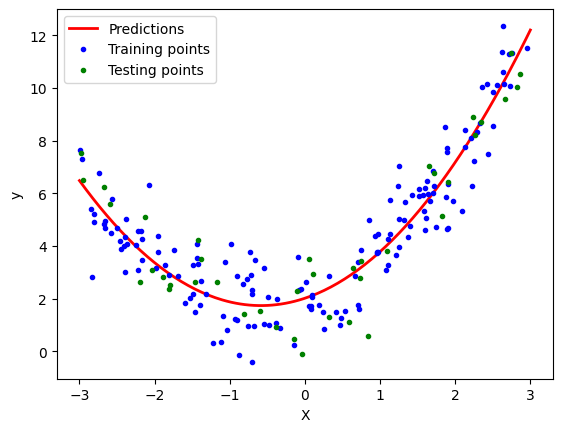

In [20]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [21]:
def polynomial_regression(degree):

    # Create smooth x values for drawing the curve
    X_new = np.linspace(-3, 3, 100).reshape(100, 1)

    # (Old line – not used now, can be removed safely)
    X_new_poly = poly.transform(X_new)

    # Step 1: create polynomial features of given degree
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)

    # Step 2: scale the features (important for high degree)
    std_scaler = StandardScaler()

    # Step 3: linear regression model
    lin_reg = LinearRegression()

    # Step 4: chain everything in one safe pipeline
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg),
    ])

    # Train the whole pipeline on original data
    polynomial_regression.fit(X, y)

    # Predict smooth curve points
    y_newbig = polynomial_regression.predict(X_new)

    # Draw the polynomial curve
    plt.plot(X_new, y_newbig, 'r', label="Degree " + str(degree), linewidth=2)

    # Plot training points (blue)
    plt.plot(X_train, y_train, "b.", linewidth=3)

    # Plot test points (green)
    plt.plot(X_test, y_test, "g.", linewidth=3)

    # Graph labels
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")

    # Fix graph window
    plt.axis([-3, 3, 0, 10])

    # Show the plot
    plt.show()


And see how the curve changes.

Degree	What happens
1	Straight line
2	Nice parabola
5	Very wiggly
10	Overfitting

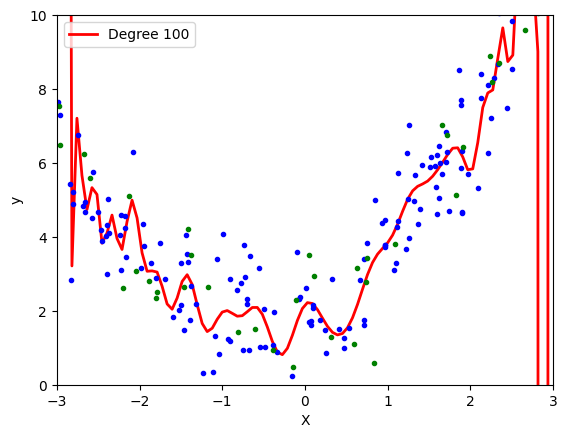

In [22]:
polynomial_regression(100)

In [25]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [26]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()